## Part 2

### Task A (spatial networks and planarity)

In [26]:
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
import spaghetti
import esda
import random
import warnings
warnings.filterwarnings('ignore')
from shapely.geometry import Point, LineString, box
from pyproj import Transformer


In [24]:
dfs = []
for year in range (2013, 2017):
    df = pd.read_csv(f'{year}.csv', encoding = 'latin1')
    if 'Expr1' in df.columns:
        df = df.drop(columns=['Expr1'])
    dfs.append(df)

accidents_df = pd.concat(dfs, axis = 0, ignore_index=True)
print(f"Total accidents (2013-2016): {len(accidents_df)}")

transformer = Transformer.from_crs("EPSG:27700", "EPSG: 4326", always_xy=True)
lons, lats = transformer.transform(
    accidents_df['Grid Ref: Easting'].values,
    accidents_df['Grid Ref: Northing'].values
)

accidents_df['Longitude'] = lons
accidents_df['Latitude'] = lats
print(accidents_df[['Grid Ref: Easting', 'Grid Ref: Northing', 'Longitude', 'Latitude']].head())

Total accidents (2013-2016): 10179
   Grid Ref: Easting  Grid Ref: Northing  Longitude   Latitude
0             426983              433434  -1.591845  53.796519
1             424366              445442  -1.630625  53.904572
2             424481              435632  -1.629653  53.816397
3             430284              432421  -1.541832  53.787234
4             430374              433485  -1.540361  53.796791


In [25]:
center_lat = 53.7997
center_lon = -1.5492

half_side = 500
lat_diff = half_side / 111000
lon_diff = half_side / 65000

north = center_lat + lat_diff
south = center_lat - lat_diff
east =  center_lon + lon_diff
west = center_lon - lon_diff

accident_points = gpd.GeoDataFrame(
    accidents_df,
    geometry=[Point(xy) for xy in zip(accidents_df['Longitude'], accidents_df['Latitude'])],
    crs="EPSG:4326"
)
area = gpd.GeoDataFrame(geometry=[box(west, south, east, north)], crs="EPSG:4326")
area_polygon = area['geometry'][0]
accidents_in_area = accident_points[accident_points.geometry.within(area_polygon)].copy()

print(f"Area: {north: .4f}N, {south: .4f}S, {east: .4f}E, {west: .4f}W")
print(f"Accidents in area: {len(accidents_in_area)}")

Area:  53.8042N,  53.7952S, -1.5415E, -1.5569W
Accidents in area: 312


Nodes: 122
Edges: 211


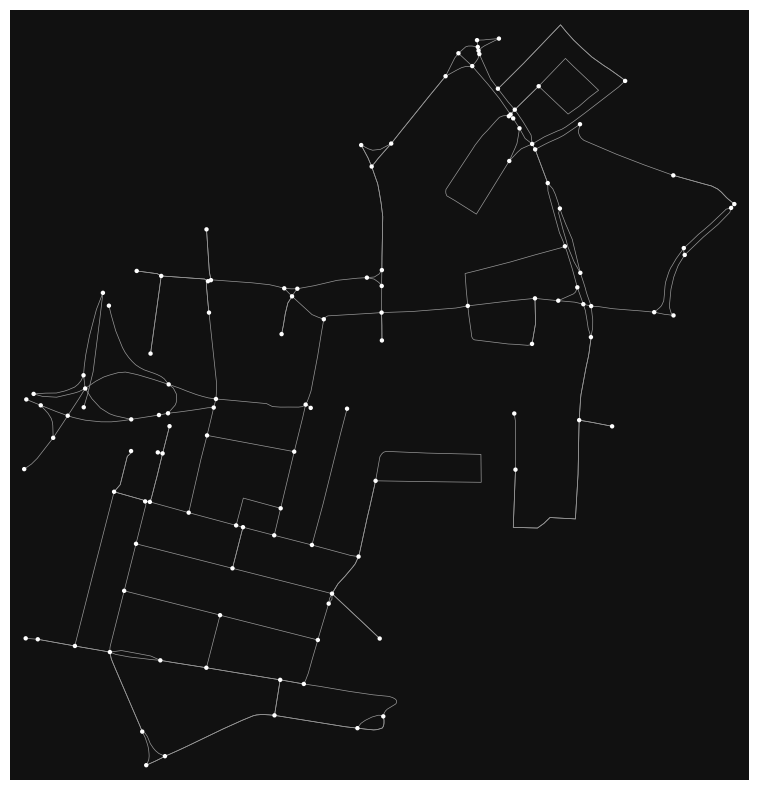

In [35]:
G = ox.graph_from_point((center_lat, center_lon), dist=500, network_type='drive')
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
fig, ax = ox.plot_graph(G, figsize=(10, 10), node_size=10, edge_linewidth=0.5)
plt.show()

In [43]:
stats = ox.basic_stats(G)

print(f"Average street length: {stats['street_length_avg']:.2f}m")
print(f"Node density (per sq km): {stats['n']/1:.2f}")
print(f"Intersection density (per sq km): {stats['intersection_count']/1:.2f}")
print(f"Edge density (per sq km): {stats['m']/1:.2f}")
print(f"Average circuity: {stats['circuity_avg']:.4f}")

if not nx.is_strongly_connected(G):
    largest_scc = max(nx.strongly_connected_components(G), key = len)
    G_connected = G.subgraph(largest_scc).copy()
    print(f"Original nodes: {G.number_of_nodes()}, Connected: {G_connected.number_of_nodes()}")
else:
    G_connected = G
    print("Graph is already strongly connected")

spatial_diameter = nx.diameter(G_connected, weight='length')
print(f"Spatial diameter: {spatial_diameter: .2f} m")

Average street length: 68.86m
Node density (per sq km): 122.00
Intersection density (per sq km): 109.00
Edge density (per sq km): 211.00
Average circuity: 1.1257
Original nodes: 122, Connected: 99
Spatial diameter:  2671.78 m


In [45]:
is_planar, kuratowski = nx.check_planarity(G, counterexample=True)
print(f"Is the network planar? {is_planar}")

if not is_planar:
    plt.figure(figsize=(12,8))
    nx.draw(kuratowski,
    pos=nx.kamada_kawai_layout(kuratowski),
    arrows=True, arrowstye='-|>', with_labels=True,
    node_size=200, font_size=6)
    pt.title("Kurarowski Subgraph(counterexample to planarity)")
    plt.show()

Is the network planar? True


#### Brief Summary
- The selected 1 km² area centered on Leeds city centre (53.7997°N, -1.5492°W) recorded 312 road traffic accidents between 2013 and 2016.

- The road network features 122 nodes and 211 edges, with a saptial diameter of 2671.78 m that exceeds the area's side length duw to the indirect nature of road paths and one-way restrictions. The network includes 13 dead-ends and was reduced to 1 99-node strongly connected component to ensure all allocations are mutually reachable for metric calculations.

- The average circuity of 1.1257 indicates that road travel is approximately 12.6% longer than straight-line distance, reflecting a fairly efficient and direct urban grid.

- The network is planar, meaning it contains no crossing edges because it lacks K5 or K3,3 subdivisions, indicating that all roads intersect at grade level without flyovers or tunnels.

### Task B (road accidents)

In [47]:
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
net = spaghetti.Network(in_data=edges_gdf)
net.snapobservations(accidents_in_area, 'accidents')

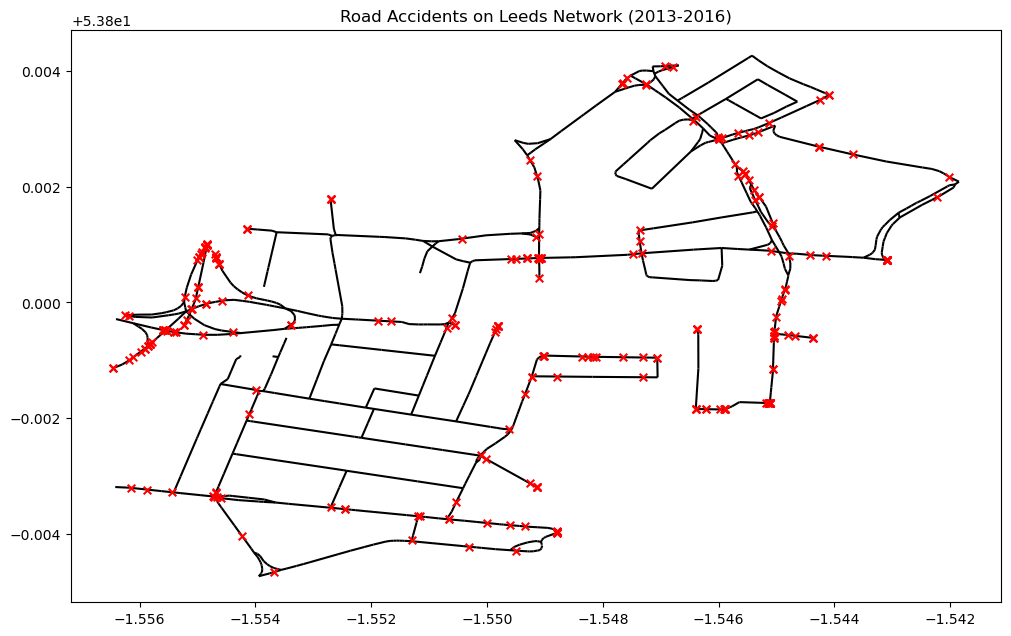

In [49]:
nodes_df, edges_df = spaghetti.element_as_gdf(net, vertices=True, arcs=True)
base = edges_df.plot(color="k", zorder=0, figsize=(12,12))

snapped = spaghetti.element_as_gdf(net, pp_name='accidents', snapped=True)
snapped.plot(color="r", marker="x",markersize=30, zorder=1, ax=base)

plt.title("Road Accidents on Leeds Network (2013-2016)")
plt.show()

In [52]:
# Calculate the K-function
kres = net.GlobalAutoK(net.pointpatterns["accidents"], nsteps=1, permutations=1)

# Calculate Moran's I
counts = net.count_per_link(net.pointpatterns['accidents'].obs_to_arc, graph=False)
weights = net.w_network
edges = weights.neighbors.keys()
values = [counts[edge] if edge in counts.keys() else 0. for index, edge in enumerate(edges)]
moran = esda.moran.Moran(values, weights)

print(f"Moran's I: {moran.I}")
print(f"P-value: {moran.p_sim}")

Moran's I: 0.07701039304461421
P-value: 0.027


Exoected Moran's I (random): -0.001218026796589525
Actual moran's I: 0.07701039304461421


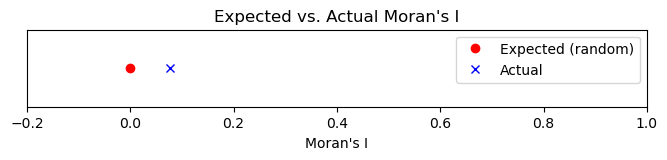

In [53]:
# Calculate the expected Moran's I under complete spatial randomness
expected_I = -1 / (len(values) -1)
print(f"Exoected Moran's I (random): {expected_I}")
print(f"Actual moran's I: {moran.I}")

plt.figure(figsize=(8,1))
plt.plot(expected_I, 0, 'ro', label="Expected (random)")
plt.plot(moran.I, 0, 'bx', label="Actual")
plt.xlim(-0.2, 1)
plt.xlabel("Moran's I")
plt.yticks([])
plt.legend()
plt.title("Expected vs. Actual Moran's I")
plt.show()

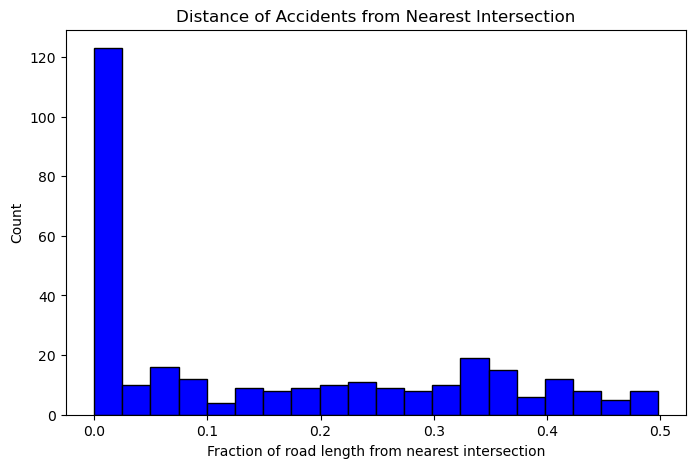

Mean distance fraction: 0.155
Median distance fraction: 0.093


In [57]:
pp = net.pointpatterns['accidents']

snap_fractions = []
for arc_id, obs_dict in pp.obs_to_arc.items():
    #arc_id = (vertex1, vertex2)
    v1_coord = np.array(net.vertex_coords[arc_id[0]])
    v2_coord = np.array(net.vertex_coords[arc_id[1]])
    arc_length = np.linalg.norm(v2_coord - v1_coord)

    if arc_length > 0:
        for obs_idx, obs_coord in obs_dict.items():
            obs_point = np.array(obs_coord)
            dist_to_v1 = np.linalg.norm(obs_point - v1_coord)
            dist_to_v2 = np.linalg.norm(obs_point - v2_coord)
            dist_to_nearest = min(dist_to_v1, dist_to_v2)
            fraction = dist_to_nearest / arc_length
            snap_fractions.append(fraction)

plt.figure(figsize=(8,5))
plt.hist(snap_fractions, bins=20, color='blue', edgecolor='black')
plt.xlabel("Fraction of road length from nearest intersection")
plt.ylabel("Count")
plt.title("Distance of Accidents from Nearest Intersection")
plt.show()

print(f"Mean distance fraction: {np.mean(snap_fractions):.3f}")
print(f"Median distance fraction: {np.median(snap_fractions):.3f}")

#### Brief Summary
- The accidents distribution plot shows that road accidents are non-uniformly distributed, concentrating on specific road segments in the western and north-eastern areas, while some road segments have no accidents at all.

- With a Moran's I value of 0.077 and a statistically significant p-value of 0.027, the analysis confirms a pattern of spatioal clustering where high-accident roads tend to ne adjacent to one another. This suggests thataccidenta are not randomly distributed bit instead from "hotspot zones" likely influenced by shared environmental factors or traffic patterns across connecting road segents.

- The histogram reveals a strong skew toward intersections, with a median distance fraction of 0.093 indicating that over half of all accidents occur within the first 9.3% of road length. 

### Task C (Voronoi diagrams)

In [ ]:
G_leeds = ox.graph_from_place("Leeds, United Kingdom", network_type='drive')
print(f"Nodes: {G_leeds.number_of_nodes()}")
print(f"Edges: {G_leeds.number_of_s()}")

Nodes: 31600
Edges: 70811


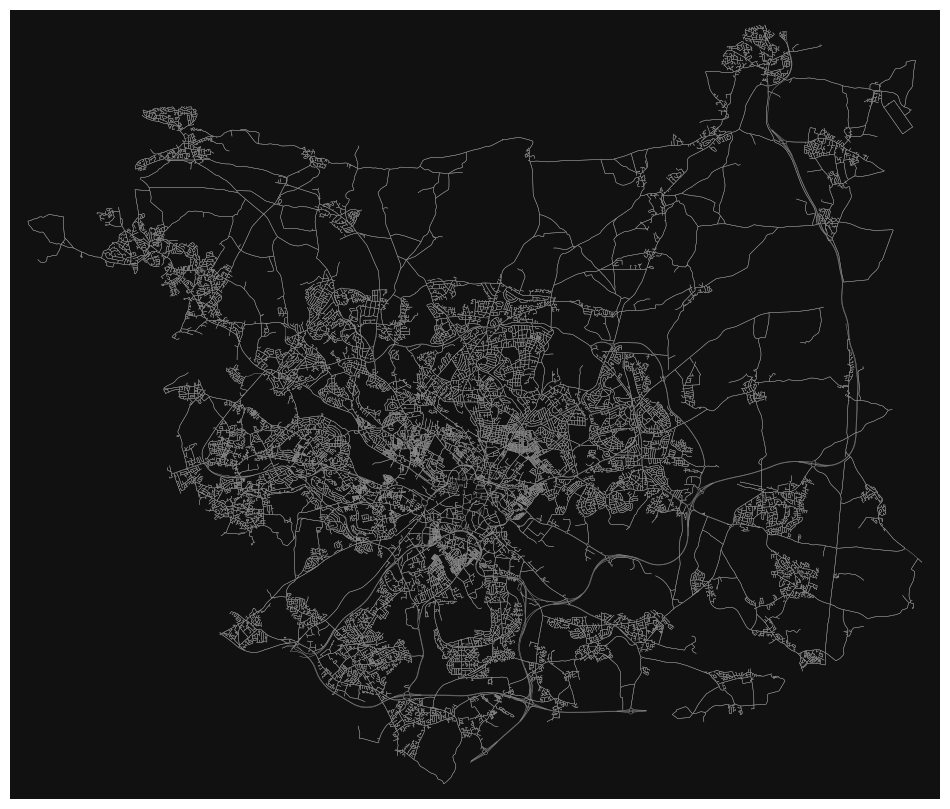

In [61]:
fig, ax = ox.plot_graph(G_leeds, figsize=(12,12), node_size = 0, edge_linewidth=0.3)
plt.show()

In [76]:
nodes_gdf = ox.graph_to_gdfs(G_leeds, edges=False)

min_lat, max_lat = nodes_gdf['y'].min(), nodes_gdf['y'].max()
min_lon, max_lon = nodes_gdf['x'].min(), nodes_gdf['x'].max()
mid_lat = (min_lat + max_lat) / 2
mid_lon = (min_lon + max_lon) / 2

print(f"Lat range: {min_lat:.4f} - {max_lat:.4f}, mid = {mid_lat:.4f}")
print(f"Lon range: {min_lon:.4f} - {max_lon:.4f}, mid = {mid_lon:.4f}")

quadrant_centers = [
    ((min_lat + mid_lat) / 2, (min_lon + mid_lon) / 2), #sw
    ((min_lat + mid_lat) / 2, (mid_lon + max_lon) / 2), #se
    ((mid_lat + max_lat) / 2, (min_lon + mid_lon) / 2), #nw
    ((mid_lat + max_lat) / 2, (mid_lon + max_lon) / 2) #ne
]
seeds = [ox.nearest_nodes(G_leeds, lon, lat) for lat, lon in quadrant_centers]
print(f"Quadrant centers; {quadrant_centers}")
print(f"Selected seeds: {seeds}")
print(f"Unique seeds: {len(set(seeds))}")

Lat range: 53.7057 - 53.9427, mid = 53.8242
Lon range: -1.7772 - -1.3041, mid = -1.5406
Quadrant centers; [(53.7649551, -1.65889175), (53.7649551, -1.42237525), (53.8834397, -1.65889175), (53.8834397, -1.42237525)]
Selected seeds: [413272851, 1951476151, 21004207, 7550996558]
Unique seeds: 4


In [77]:
cells = nx.voronoi_cells(G_leeds, seeds, weight='length')
cells_inverse = {v: key for key, value in cells.items() for v in value}

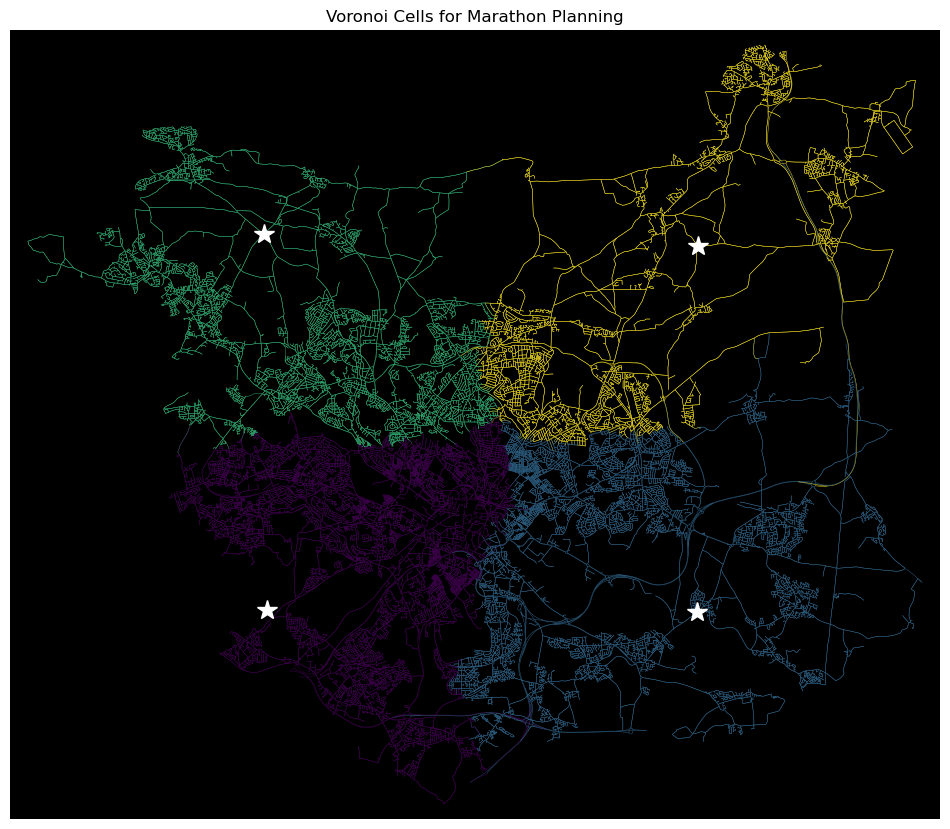

In [81]:
colours = ox.plot.get_colors(len(seeds))
seed_colors = dict(zip(seeds, colours))
seed_colors['unreachable'] = 'k'

edge_colors = []
for u, v, _ in G_leeds.edges(data=True):
    color_u = seed_colors.get(cells_inverse.get(u, 'unreachable'), 'k')
    color_v = seed_colors.get(cells_inverse.get(v, 'unreachable'), 'k')
    edge_colors.append(color_u)

node_colors = ['r' if node in seeds else 'w' for node in G_leeds.nodes()]

fig, ax = ox.plot_graph(G_leeds, edge_color=edge_colors, node_color=node_colors,
                        node_size=0, edge_linewidth=0.3, bgcolor='k',
                        figsize=(12,12), show=False, close=False)
for s in seeds:
    ax.plot(G_leeds.nodes[s]['x'], G_leeds.nodes[s]['y'],
            'w*', markersize=15)
    
ax.set_title("Voronoi Cells for Marathon Planning")
plt.show()

In [90]:
cell_subgraphs = {}

for seed in seeds:
    cell_nodes = cells[seed]
    subgraph = G_leeds.subgraph(cell_nodes).copy()

    total_length = sum(data.get('length', 0) for u, v, data in subgraph.edges(data=True))
    
    print(f"Seed {seed}: {subgraph.number_of_nodes()} nodes,"
          f"{subgraph.number_of_edges()} edges, "
          f"total road length = {total_length/1000:1f} km")

Seed 413272851: 11909 nodes,26548 edges, total road length = 1920.100644 km
Seed 1951476151: 9279 nodes,20435 edges, total road length = 1702.196600 km
Seed 21004207: 6543 nodes,14834 edges, total road length = 1354.455706 km
Seed 7550996558: 3848 nodes,8612 edges, total road length = 988.536623 km


In [122]:
random.seed(42)
def find_marathon_loop(G_sub, seed, target=42000, tol=2000):
    best_loop = None
    best_diff = float('inf')

    distances = nx.single_source_dijkstra_path_length(
        G_sub, seed, weight='length')
    
    reachable = [n for n in distances if n != seed]

    for attempt in range(100):
        n_waypoints = random.randint(3, 6)
        if len(reachable) < n_waypoints:
            continue
        waypoints = random.sample(reachable, n_waypoints)

        def angle_from_seed(node):
            dx = G_sub.nodes[node]['x'] - G_sub.nodes[seed]['x']
            dy = G_sub.nodes[node]['y'] - G_sub.nodes[seed]['y']
            return math.atan2(dy, dx)
        
        waypoints.sort(key=angle_from_seed)

        route_nodes = [seed] + waypoints + [seed]

        full_path = []
        total_distance = 0
        valid = True

        for j in range(len(route_nodes) - 1):
            try:
                seg = nx.shortest_path(
                    G_sub, route_nodes[j], route_nodes[j+1], weight='length')
                seg_len = nx.shortest_path_length(
                    G_sub, route_nodes[j], route_nodes[j+1], weight='length')
                
                if j == 0:
                    full_path.extend(seg)
                else:
                    full_path.extend(seg[1:])
                total_distance += seg_len
            except nx.NetworkXNoPath:
                valid = False
                break
        if not valid:
            continue

        diff = abs(total_distance - target)
        if diff < best_diff:
            best_diff = diff
            best_loop = {
                'full_path': full_path,
                'total_distance': total_distance,
                'n_waypoints': n_waypoints
            }
        if diff < tol:
            return best_loop
    return best_loop


import math
results = {}
for i, seed in enumerate(seeds):
    print(f"\n--- Cell {i+1} (Seed {seed}) ---")
    G_sub = G_leeds.subgraph(cells[seed]).copy()
    result = find_marathon_loop(G_sub, seed)
    if result:
        print(f"Total distance: {result['total_distance']/1000:.2f} km")
        print(f"Waypoints used: {result['n_waypoints']}")
        results[seed] = result
    else:
        print("No loop found within tolarance")


--- Cell 1 (Seed 413272851) ---
Total distance: 43.37 km
Waypoints used: 6

--- Cell 2 (Seed 1951476151) ---
Total distance: 41.22 km
Waypoints used: 3

--- Cell 3 (Seed 21004207) ---
Total distance: 42.03 km
Waypoints used: 5

--- Cell 4 (Seed 7550996558) ---
Total distance: 42.63 km
Waypoints used: 6


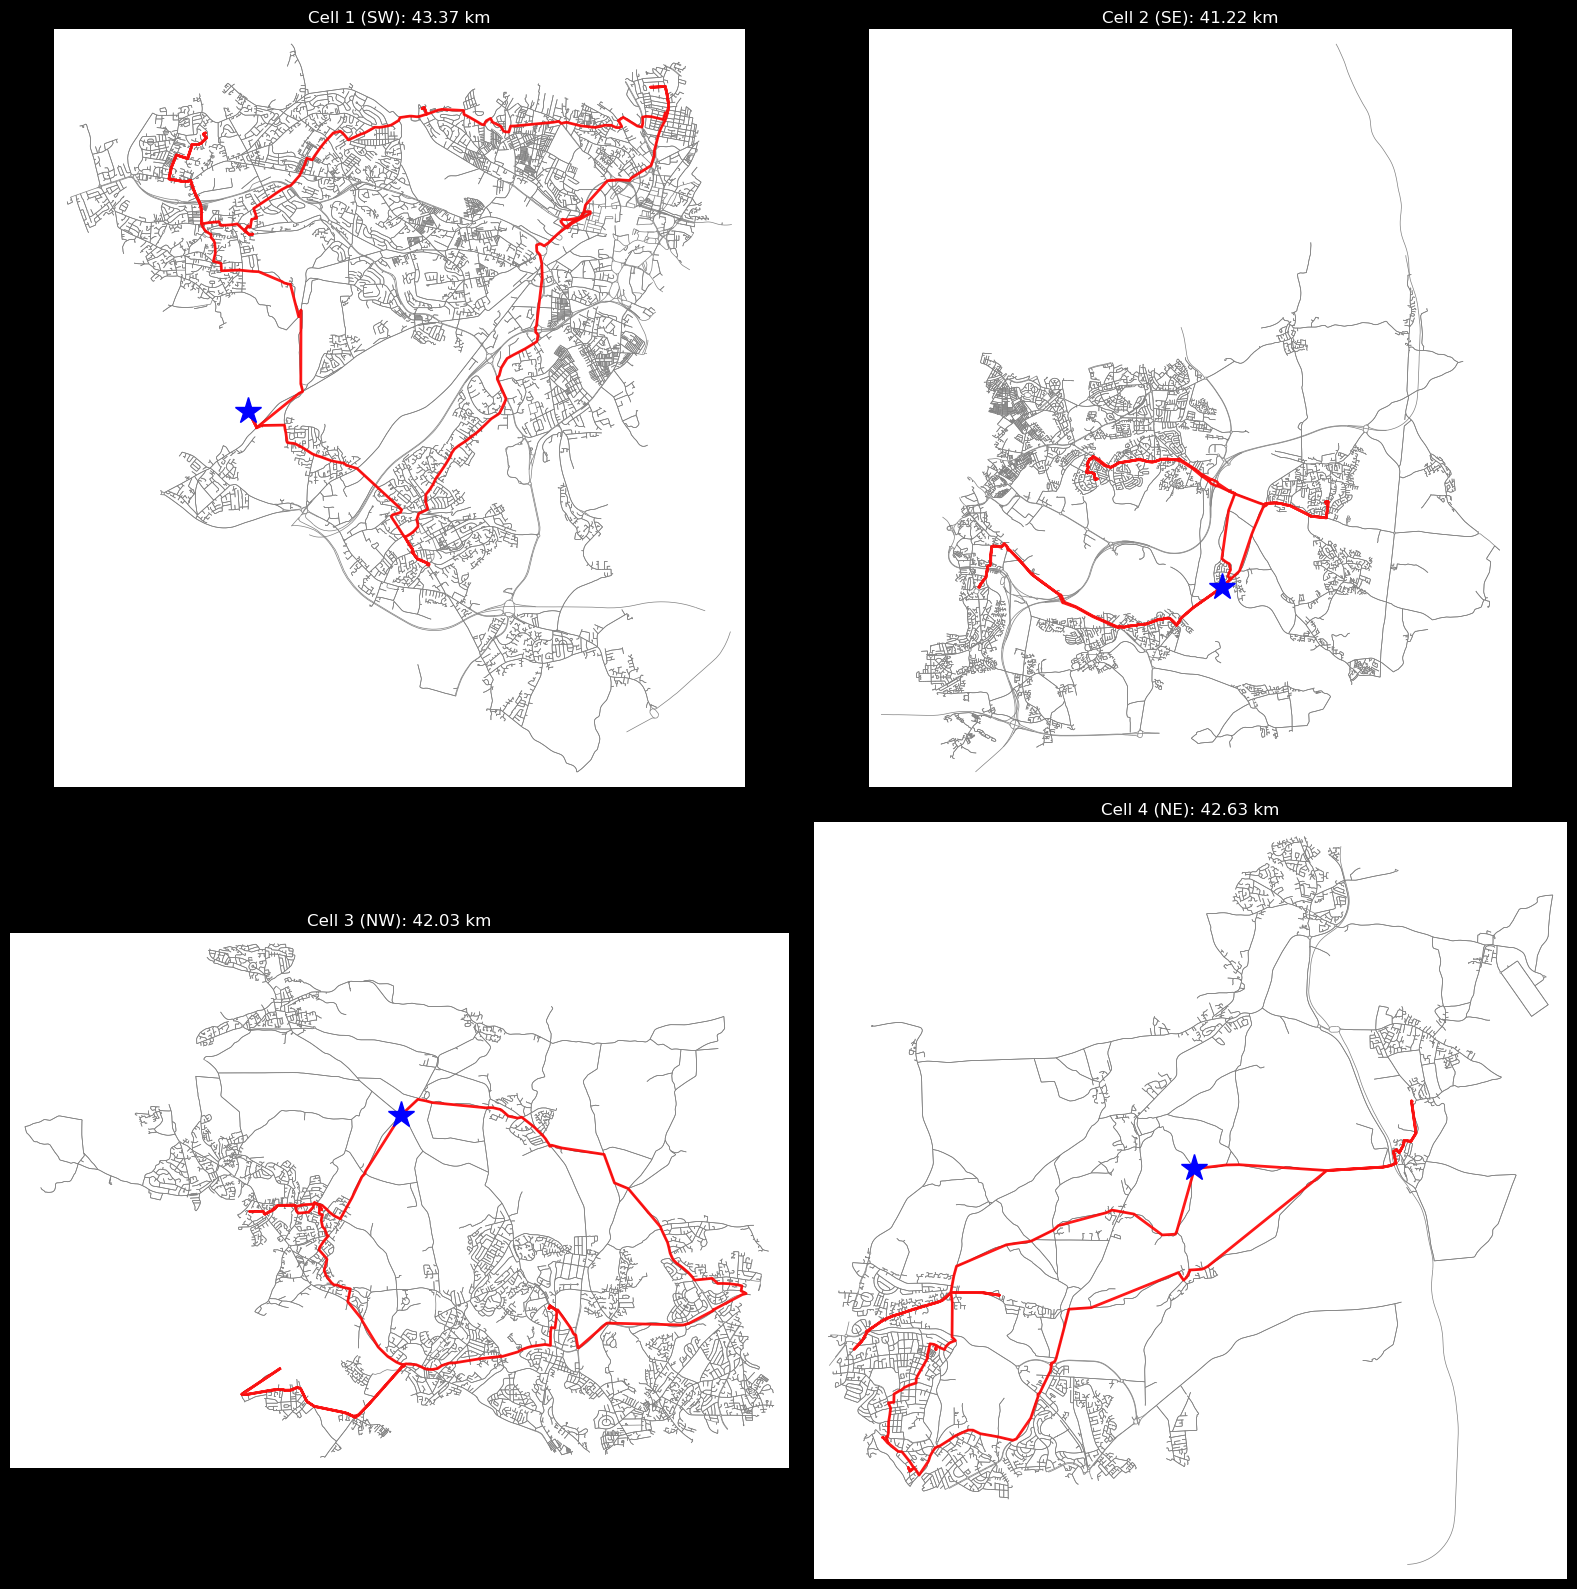

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(16,16), facecolor='k')
axes = axes.flatten()
cell_labels = ['SW', 'SE', 'NW', 'NE']

for i, seed in enumerate(seeds):
    ax = axes[i]
    G_sub = G_leeds.subgraph(cells[seed]).copy()
    ox.plot_graph(G_sub, ax=ax, node_size=0, edge_linewidth=0.5,
                  edge_color='gray', bgcolor='k', show=False, close=False)

    if seed in results:
        result = results[seed]
        path_lons = [G_leeds.nodes[n]['x'] for n in result['full_path']]
        path_lats = [G_leeds.nodes[n]['y'] for n in result['full_path']]
        ax.plot(path_lons, path_lats, color='red', linewidth=2, alpha=0.9)

    ax.plot(G_leeds.nodes[seed]['x'], G_leeds.nodes[seed]['y'], 'b*', markersize=20)
    
    dist = results[seed]['total_distance']/1000 if seed in results else 0
    ax.set_title(f"Cell {i+1} ({cell_labels[i]}): {dist:.2f} km", color='white', fontsize=12)

plt.tight_layout()
plt.show()

In [127]:
random.seed(42)
seeds_3 = seeds[:3]
print(f"Seeds (N=3): {seeds_3}")

cells_3 = nx.voronoi_cells(G_leeds, seeds_3, weight = 'length')

results_3 = {}
for i, seed in enumerate(seeds_3):
    print(f"\n--- Cell {i+1} (Seed {seed}) ---")
    G_sub = G_leeds.subgraph(cells_3[seed]).copy()
    total_length = sum(d.get('length', 0) for u, v, d in G_sub.edges(data=True))
    print(f"Total road length: {total_length/1000: .1f} km")

    result = find_marathon_loop(G_sub, seed)
    if result:
        print(f"Total distance: {result['total_distance']/1000:.2f} km")
        print(f"Waypoints used: {result['n_waypoints']}")
        results_3[seed] = result
    else:
        print("No loop found within tolarance")

Seeds (N=3): [413272851, 1951476151, 21004207]

--- Cell 1 (Seed 413272851) ---
Total road length:  1920.1 km
Total distance: 43.37 km
Waypoints used: 6

--- Cell 2 (Seed 1951476151) ---
Total road length:  2284.3 km
Total distance: 40.59 km
Waypoints used: 6

--- Cell 3 (Seed 21004207) ---
Total road length:  1767.0 km
Total distance: 42.28 km
Waypoints used: 6


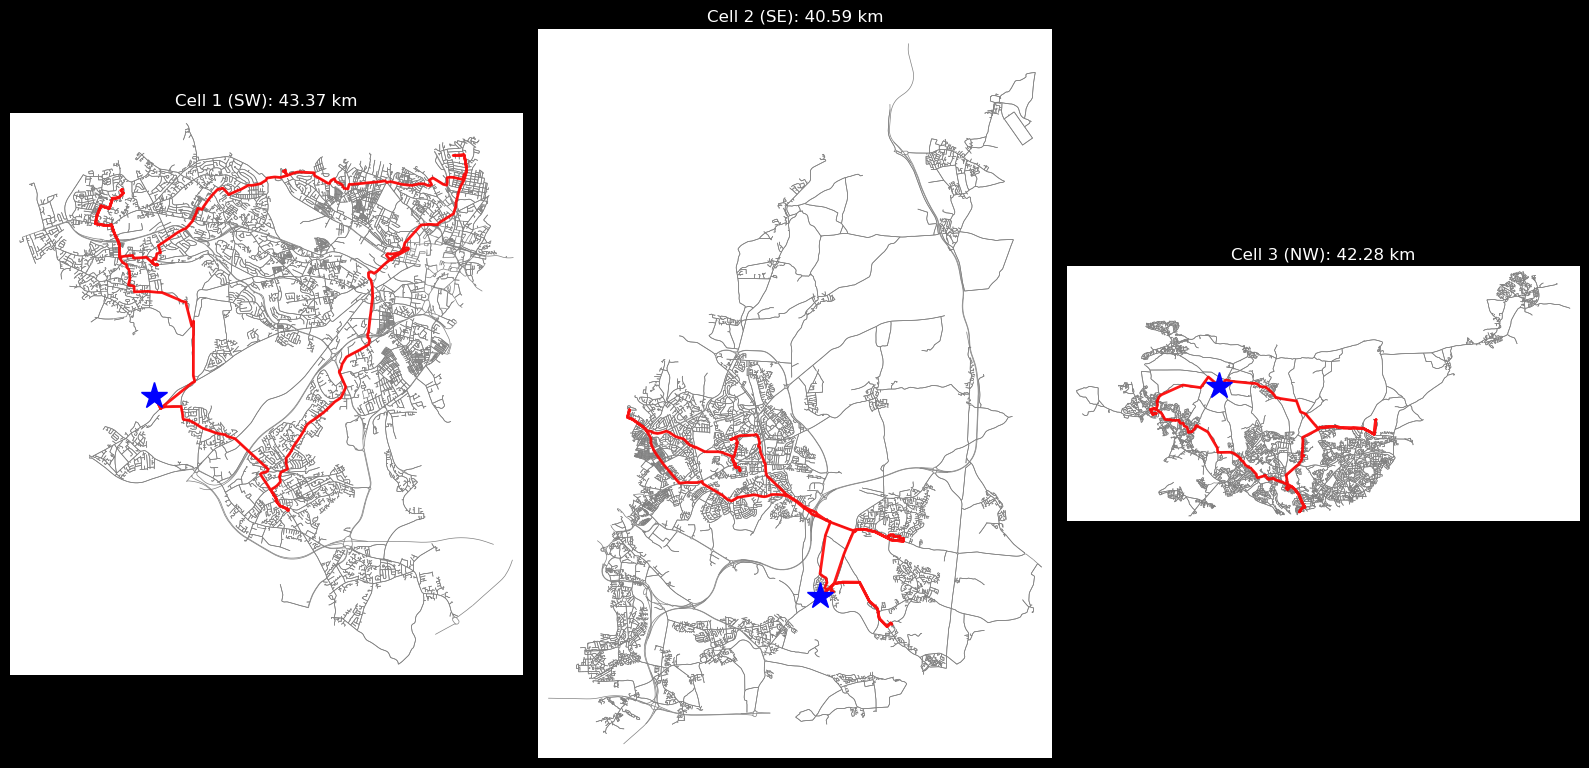

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(16,16), facecolor='k')
axes = axes.flatten()
cell_labels = ['SW', 'SE', 'NW']

for i, seed in enumerate(seeds_3):
    ax = axes[i]
    G_sub = G_leeds.subgraph(cells_3[seed]).copy()
    ox.plot_graph(G_sub, ax=ax, node_size=0, edge_linewidth=0.5,
                  edge_color='gray', bgcolor='k', show=False, close=False)

    if seed in results_3:
        result = results_3[seed]
        path_lons = [G_leeds.nodes[n]['x'] for n in result['full_path']]
        path_lats = [G_leeds.nodes[n]['y'] for n in result['full_path']]
        ax.plot(path_lons, path_lats, color='red', linewidth=2, alpha=0.9)

    ax.plot(G_leeds.nodes[seed]['x'], G_leeds.nodes[seed]['y'], 'b*', markersize=20)
    
    dist = results_3[seed]['total_distance']/1000 if seed in results_3 else 0
    ax.set_title(f"Cell {i+1} ({cell_labels[i]}): {dist:.2f} km", color='white', fontsize=12)

plt.tight_layout()
plt.show()

#### Brief Summary
- By dividing the Leeds road network into four quadrants and placing seed points at their respective centers, this strategy ensures a uniform distribution that maximizes participation and minimizes travel distances for residents.

- A node network Voronoi diagram was selected to partition tje Leeds road network based on shortest path distances, ensuring each node is assigned to its closest marathon seed point. This approach is more suitable for route planning than Euclidean-based or edge-point methods, as it directly aligns with how NetorkX constructs path while accounting for actual road network structures like barriers and ine-way streets.

- A multi-waypoint loop algorithm was developed to construct circular marathon routes by connecting randomly selected nodes in an angular order, ensuring a closed path that avoids self-intersection. By iterating through different waypoint combinations and calculating shortest-path distances, the process successfully identified reproducible ~42 km routes within each cell's extensive road network.

- To increase the likelihood of finding valid marathon routes in sparser areas, strategies such as reducing the number of seeds, relocating them to road-dense areas, or expanding the study boundary can provide more routing options. Experimental validation showed that reducing to three seeds allowed remaining cells to absorb more road length, though the original four-seed configuration was already sufficient for a dense network like Leeds.